# Linear Regression

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import linregress
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [3]:
df = pd.read_csv('RegData_new.csv')

In [4]:
df.head()

,Unnamed: 0,StID,SAT,GPA
0,0,101,1355,3.42
1,1,102,1391,3.48
2,2,103,1170,2.91
3,3,104,1357,3.41
4,4,105,1326,3.28


In [5]:
X = df["SAT"]
Y = df["GPA"]


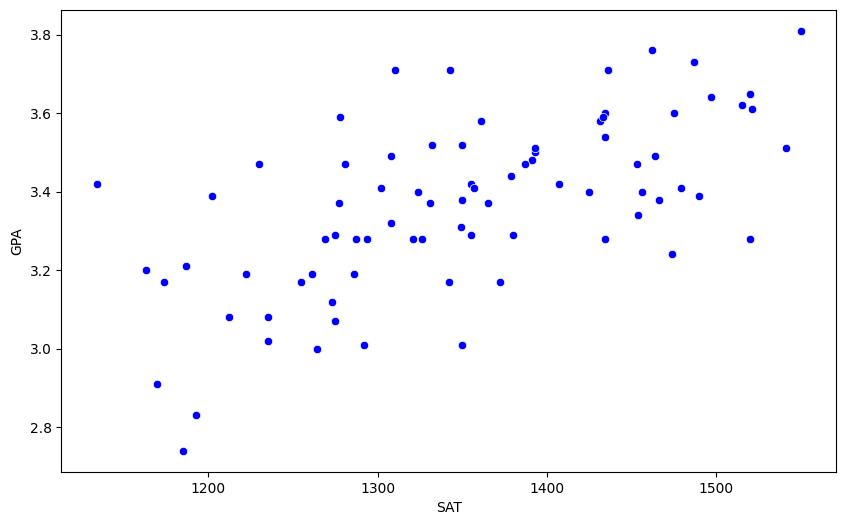

In [6]:
plt.figure(figsize=(10,6))
sns.scatterplot(x =X, y=Y, color="blue")
plt.xlabel("SAT")
plt.ylabel("GPA")
plt.show()

In [7]:
corr = df[["SAT", "GPA"]].corr()

<Axes: >

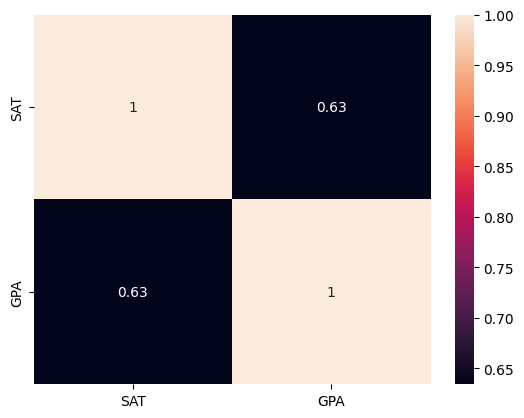

In [8]:
sns.heatmap(corr, annot=True)

In [9]:
slope, intercept, r_value, p_value, std_err = linregress(X,Y)

In [10]:
print(f"Slope : {slope}")
print(f"Intercept : {intercept}")
print(f"Y = {round(slope, 3)}X + {round(intercept, 2)}")

Slope : 0.0013600349643199277
Intercept : 1.5251824213228533
Y = 0.001X + 1.53


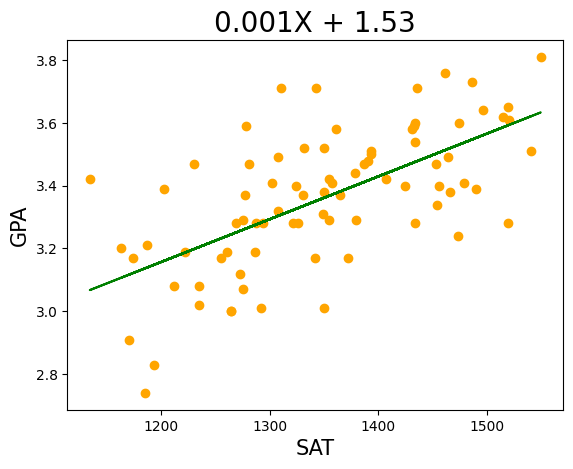

In [11]:
y1 = slope*X + intercept
plt.scatter(X, Y, color="orange")
plt.plot(X, y1, color="green")
plt.xlabel("SAT", fontsize=15)
plt.ylabel("GPA", fontsize=15)
plt.title(f"{round(slope, 3)}X + {round(intercept, 2)}", fontsize=20)
plt.show()

## Prediction

In [12]:
givenSAT = 1450
predGPA = slope*givenSAT + intercept
predGPA

np.float64(3.4972331195867485)

In [13]:
y2 = df["GPA"]
df_pred = pd.DataFrame({"Actual Data" : y2, "Predicted Data": round(y1,2)})
df_pred.head()

,Actual Data,Predicted Data
0,3.42,3.37
1,3.48,3.42
2,2.91,3.12
3,3.41,3.37
4,3.28,3.33


<Axes: >

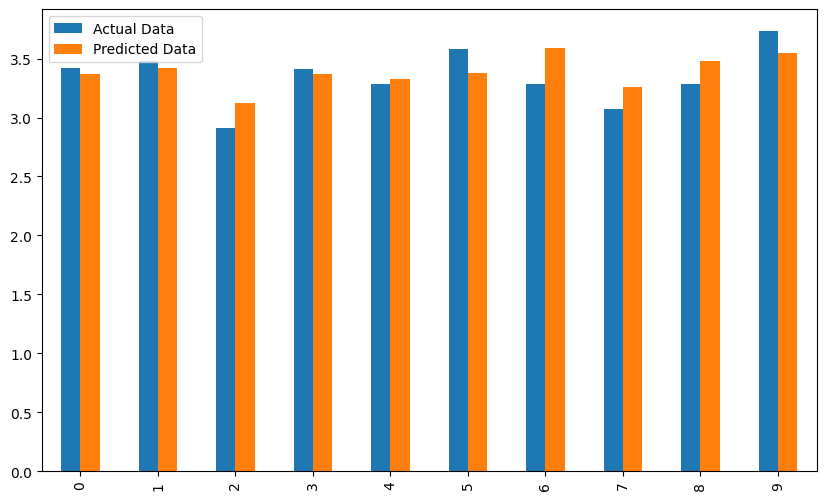

In [14]:
df_pred.head(10).plot(kind="bar", figsize=(10,6))

In [15]:
df_1_p = pd.DataFrame({**df, "PredictedGPA" : y1})
df_1_p

,Unnamed: 0,StID,SAT,GPA,PredictedGPA
0,0,101,1355,3.42,3.368030
1,1,102,1391,3.48,3.416991
2,2,103,1170,2.91,3.116423
3,3,104,1357,3.41,3.370750
4,4,105,1326,3.28,3.328589
...,...,...,...,...,...
76,79,193,1365,3.37,3.381630
77,80,195,1479,3.41,3.536674
78,81,196,1324,3.40,3.325869
79,82,197,1294,3.28,3.285068


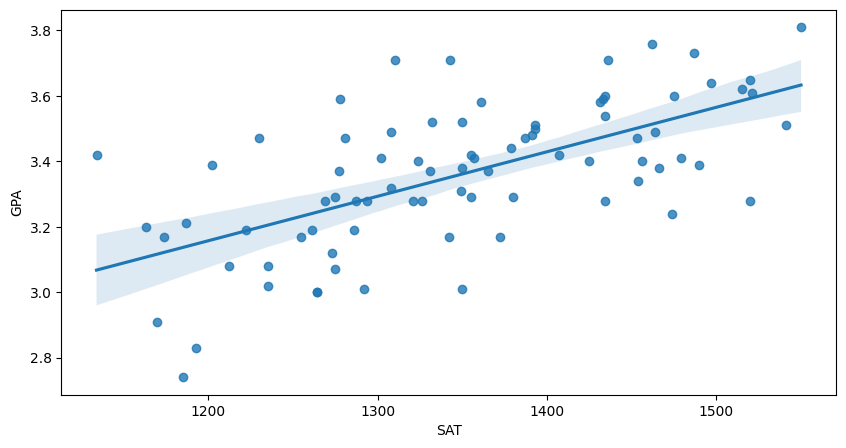

In [16]:
plt.figure(figsize=(10,5))
p = sns.regplot(data=df, x=df["SAT"], y=df["GPA"])

<Axes: xlabel='SAT', ylabel='GPA'>

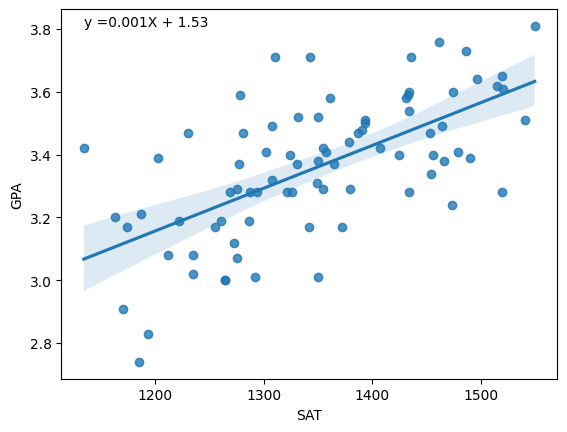

In [17]:
plt.text(min(df["SAT"]), max(df["GPA"]), f"y ={round(slope, 3)}X + {round(intercept, 2)}")
sns.regplot(data=df, x=df["SAT"], y=df["GPA"])

In [18]:
X = df[["SAT"]]
Y = df["GPA"]
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=1)

In [19]:
clf = LinearRegression()

In [20]:
model = clf.fit(x_train, y_train)

In [21]:
y_pred = model.predict(x_test)

In [22]:
y = pd.DataFrame({"Actual" : y_test, "Predicted" : y_pred})
y.head()

,Actual,Predicted
63,3.76,3.504437
27,3.65,3.573986
31,3.19,3.293393
69,3.00,3.267013
46,3.17,3.159093


<Axes: >

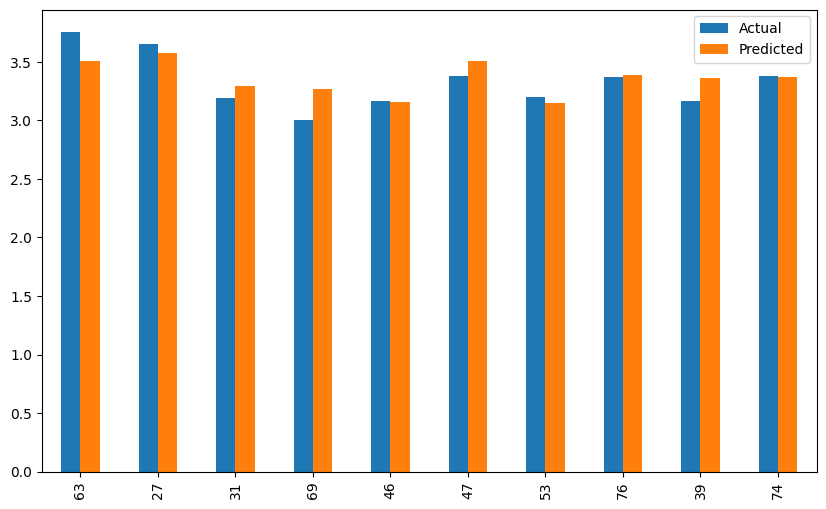

In [23]:
y.head(10).plot(kind="bar", figsize=(10,6))

In [24]:
print("MAE\t\t", metrics.mean_absolute_error(y_test, y_pred))
print("MSE\t\t", metrics.mean_squared_error(y_test, y_pred))
print("RMSE\t\t", metrics.mean_squared_error(y_test, y_pred)**0.5)
print("R_Squared\t", metrics.r2_score(y_test, y_pred))

MAE		 0.1364566158325926
MSE		 0.030593767925858665
RMSE		 0.17491074274000057
R_Squared	 0.5115887530482646


In [25]:
model.score(x_test, y_test)

0.5115887530482646

If RMSE > MSE , There is high variation.

# Gradient Descent

In [26]:
b0 =0
b1 = 0
learning_rate = 0.0000001
epochs =  1000
n = float(len(x_train))

In [27]:
x_vals = x_train.values.flatten()
y_vals = y_train.to_numpy()
x_vals

array([1431, 1212, 1343, 1235, 1294, 1331, 1387, 1541, 1264, 1379, 1350,
       1255, 1357, 1235, 1269, 1281, 1308, 1393, 1434, 1230, 1355, 1324,
       1434, 1275, 1479, 1222, 1273, 1349, 1464, 1436, 1134, 1308, 1277,
       1372, 1454, 1326, 1278, 1275, 1475, 1407, 1321, 1434, 1187, 1393,
       1185, 1520, 1433, 1391, 1474, 1456, 1361, 1202, 1487, 1193, 1302,
       1425])

In [28]:
for i in range(epochs):
    y_current = b1*x_vals + b0

    D_b1 = (-2/n) * sum(x_vals * (y_vals - y_current))
    D_b0 = (-2/n) * sum(y_vals - y_current)
    b1 = b1 - learning_rate * D_b1
    b0 = b0 - learning_rate * D_b0
print(f"Final intercept (b0) : {b0}")
print(f"Final slope (b1) : {b1}")

Final intercept (b0) : 3.620987463433299e-06
Final slope (b1) : 0.002496526685303687


In [29]:
y_pred_gd = b1 * x_test + b0


In [30]:
print("MAE\t\t", metrics.mean_absolute_error(y_test, y_pred_gd))
print("MSE\t\t", metrics.mean_squared_error(y_test, y_pred_gd))
print("RMSE\t\t", metrics.mean_squared_error(y_test, y_pred_gd)**0.5)
print("R_Squared\t", metrics.r2_score(y_test, y_pred_gd))

MAE		 0.16182890906899838
MSE		 0.03878283121884255
RMSE		 0.1969335705735377
R_Squared	 0.38085524470807897
